# Customer Intelligence System using classification, ensemble & clustering.
End-to-End ML Pipeline

# Library Imports


In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Load Data


In [26]:
df = pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Data Overview


In [27]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(167, 10)
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
0


# Correlation Heatmap


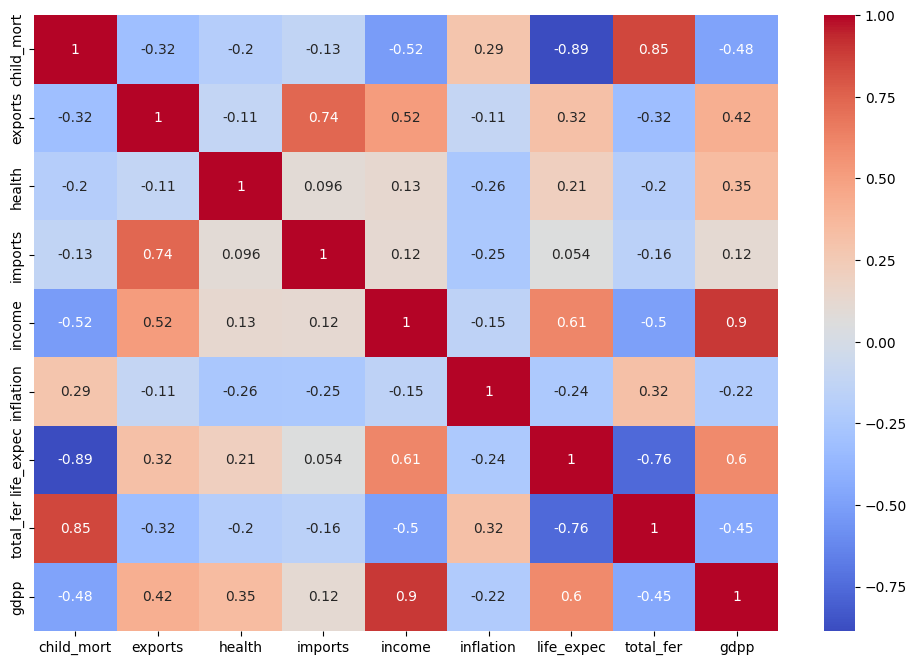

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Feature Scaling


In [29]:
X = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Elbow Method


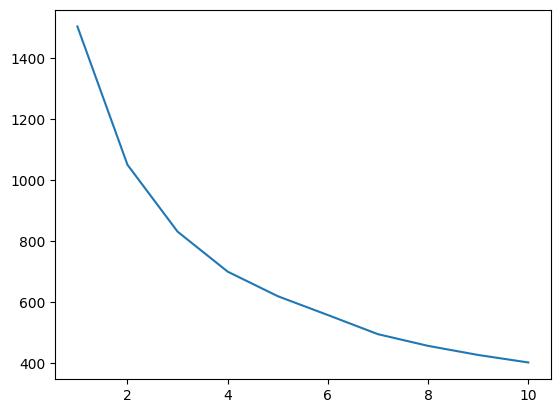

In [30]:
inertia=[]
for k in range(1,11):
    km=KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia)
plt.show()

#Silhoutte Score


In [31]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(k, score)

2 0.28735668921406704
3 0.28329575683463126
4 0.29595170577528157
5 0.2992594995920442
6 0.22869157246806018
7 0.2476808104838398
8 0.23881101831198853
9 0.20731224410666968
10 0.20223005028962746


# K-Means


In [32]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(
    X_scaled
)

# DBscan

In [33]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(
    X_scaled
)

#Cluster Profiling

In [34]:
cluster_profile = df.groupby(
    "KMeans_Cluster"
).mean(numeric_only=True)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444,-0.250000
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979,-0.340426
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381,-0.059524


#Create Target

In [35]:
df["Development_Class"] = df[
    "KMeans_Cluster"
]

X = df.drop(
    [
        "country",
        "KMeans_Cluster",
        "DBSCAN_Cluster",
        "Development_Class"
    ],
    axis=1
)

y = df["Development_Class"]

### Prepare Data for Classification


In [36]:
df['Development_Class']=df['KMeans_Cluster']

X=df.drop(['country','KMeans_Cluster','DBSCAN_Cluster','Development_Class'],axis=1)
y=df['Development_Class']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

### Random Forest Classifier


In [37]:
rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42)
rf.fit(X_train,y_train)
pred=rf.predict(X_test)
print('RF Accuracy:',accuracy_score(y_test,pred))

RF Accuracy: 1.0


### XGBoost Classifier


In [38]:
xgb=XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss')
xgb.fit(X_train,y_train)
pred=xgb.predict(X_test)
print('XGB Accuracy:',accuracy_score(y_test,pred))

XGB Accuracy: 0.9705882352941176


### Ensemble Classifier


In [39]:
ensemble=VotingClassifier(
    estimators=[('rf',rf),('xgb',xgb)],
    voting='hard')
ensemble.fit(X_train,y_train)
pred=ensemble.predict(X_test)
print('Ensemble Accuracy:',accuracy_score(y_test,pred))

Ensemble Accuracy: 1.0


#HyperParameter Tuning XGB

In [40]:
params = {
    "n_estimators":[100,200,300],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        eval_metric="mlogloss"
    ),
    params,
    cv=5,
    scoring="accuracy"
)

grid_xgb.fit(
    X_train,
    y_train
)

print(
    grid_xgb.best_params_
)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


### Feature Importance


In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.251179
8,gdpp,0.199593
7,total_fer,0.174030
6,life_expec,0.161208
4,income,0.144110
2,health,0.031770
5,inflation,0.016104
3,imports,0.011648
1,exports,0.010357
